# Dimensionality Reduction

To a computer a garment photo is just 784 little numbers - but those pixels are far from strangers to one another: fabric moves in blocks, sleeves and hems sit in fairly predictable places. PCA is the tool that finds the handful of directions doing most of the work, and honestly I find the result quietly beautiful — you can literally see the "average garment" and the ghostly shapes the data cares about most. Here I build PCA myself, use it to shrink the images, and show that a classifier barely notices the difference.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

npz = np.load(DATA / "fashion_mnist_subset.npz", allow_pickle=True)
X_train = npz["X_train"].reshape(len(npz["X_train"]), -1).astype(float) / 255.0
X_test = npz["X_test"].reshape(len(npz["X_test"]), -1).astype(float) / 255.0
y_train, y_test = npz["y_train"], npz["y_test"]
class_names = list(npz["class_names"])
print("flattened pixels:", X_train.shape, X_test.shape, "| 10 classes")

flattened pixels: (6000, 784) (1000, 784) | 10 classes


## 1. PCA from scratch

Centre the data and form the covariance matrix

$$
\Sigma = \frac{1}{n-1} X_c^\top X_c \in \mathbb{R}^{784\times784}, \qquad X_c = X - \bar X.
$$

$\Sigma$ is symmetric and positive semi-definite, so it has an orthonormal eigen-decomposition $\Sigma = V \Lambda V^\top$. The eigenvectors $v_1, v_2, \dots$ sorted by eigenvalue $\lambda_1 \ge \lambda_2 \ge \dots$ are the principal components - orthogonal directions of decreasing variance. Projecting onto the top $k$ of them,

$$
Z = X_c V_k, \qquad V_k = [v_1, \dots, v_k],
$$

gives the best $k$-dimensional linear summary in the least-squares sense. Each component explains a fraction $\lambda_i / \sum_j \lambda_j$ of the total variance.

In [3]:
class PCA:
    '''Principal Component Analysis via eigen-decomposition of the covariance matrix.'''
    def __init__(self, n_components: int | None = None):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, float)
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        cov = np.cov(Xc, rowvar=False)
        vals, vecs = np.linalg.eigh(cov)          # ascending eigenvalues
        order = np.argsort(vals)[::-1]             # sort descending
        self.eigenvalues_ = vals[order]
        self.eigenvectors_ = vecs[:, order]        # columns are components
        self.explained_variance_ratio_ = self.eigenvalues_ / self.eigenvalues_.sum()
        return self

    def transform(self, X, k: int | None = None):
        k = k or self.n_components or self.eigenvectors_.shape[1]
        return (np.asarray(X, float) - self.mean_) @ self.eigenvectors_[:, :k]

    def inverse_transform(self, Z):
        k = Z.shape[1]
        return Z @ self.eigenvectors_[:, :k].T + self.mean_

pca = PCA().fit(X_train)
print("first 5 explained-variance ratios:",
      np.round(pca.explained_variance_ratio_[:5], 3))

# Validate against scikit-learn.
from sklearn.decomposition import PCA as SkPCA
sk = SkPCA(n_components=10, random_state=SEED).fit(X_train)
print("max |ours - sklearn| (top-10 ratios):",
      f"{np.max(np.abs(pca.explained_variance_ratio_[:10] - sk.explained_variance_ratio_)):.2e}")

first 5 explained-variance ratios: [0.291 0.179 0.06  0.049 0.038]
max |ours - sklearn| (top-10 ratios): 1.07e-10


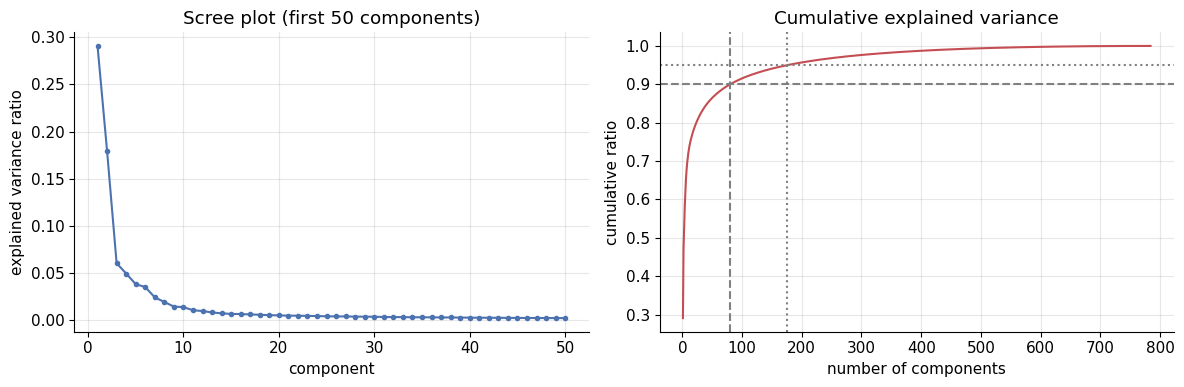

80 components explain 90% of the variance; 176 explain 95% (vs 784 original pixels).


In [4]:
cum = np.cumsum(pca.explained_variance_ratio_)
k90 = int(np.searchsorted(cum, 0.90) + 1)
k95 = int(np.searchsorted(cum, 0.95) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, 51), pca.explained_variance_ratio_[:50], "o-", color="#4C72B0", ms=3)
ax[0].set_title("Scree plot (first 50 components)")
ax[0].set_xlabel("component"); ax[0].set_ylabel("explained variance ratio")
ax[1].plot(range(1, len(cum) + 1), cum, color="#C44E52")
ax[1].axhline(0.90, ls="--", color="gray"); ax[1].axhline(0.95, ls=":", color="gray")
ax[1].axvline(k90, ls="--", color="gray"); ax[1].axvline(k95, ls=":", color="gray")
ax[1].set_title("Cumulative explained variance")
ax[1].set_xlabel("number of components"); ax[1].set_ylabel("cumulative ratio")
plt.tight_layout(); plt.show()
print(f"{k90} components explain 90% of the variance; {k95} explain 95% "
      f"(vs 784 original pixels).")

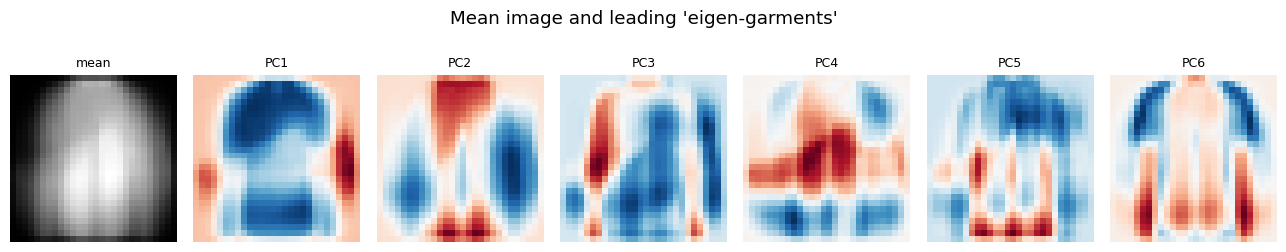

In [5]:
# The mean garment and the first principal components, reshaped back to 28x28.
fig, axes = plt.subplots(1, 7, figsize=(13, 2.4))
axes[0].imshow(pca.mean_.reshape(28, 28), cmap="gray"); axes[0].set_title("mean", fontsize=9)
for i in range(6):
    comp = pca.eigenvectors_[:, i].reshape(28, 28)
    axes[i + 1].imshow(comp, cmap="RdBu"); axes[i + 1].set_title(f"PC{i+1}", fontsize=9)
for ax in axes: ax.axis("off")
fig.suptitle("Mean image and leading 'eigen-garments'", y=1.05)
plt.tight_layout(); plt.show()

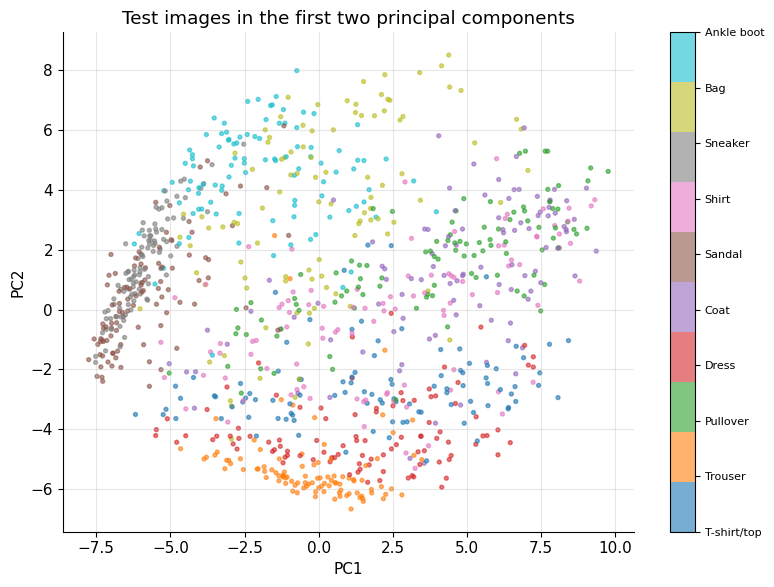

In [6]:
# Project the test set onto the first two components and colour by class.
Z2 = pca.transform(X_test, k=2)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.6)
ax.set_title("Test images in the first two principal components")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
cb = fig.colorbar(sc, ticks=range(10)); cb.ax.set_yticklabels(class_names, fontsize=8)
plt.tight_layout(); plt.show()

What I love here is that even squeezed into just two dimensions, the wardrobe sorts itself out - shoes drift to one side, bags to another, the big flowy pieces somewhere else entirely. And the places where the classes blur into each other (shirt, pullover, coat - honestly, can you always tell them apart from a tiny grey thumbnail?) are exactly where the classifier will hesitate too.

## 2. PCA as preprocessing for a softmax classifier

Now we classify garment type on the compressed features. Softmax regression generalises logistic regression to $K$ classes: with class scores $s = W^\top x + b$,

$$
P(y = k \mid x) = \frac{e^{s_k}}{\sum_{j=1}^{K} e^{s_j}},
$$

trained by minimising the categorical cross-entropy $-\frac{1}{n}\sum_i \log P(y_i\mid x_i)$. Its gradient on the logits is simply $P - Y$ (with one-hot $Y$). We standardise the PCA scores first so gradient descent is well-scaled.

In [7]:
def softmax(Z):
    Z = np.asarray(Z, float) - np.max(Z, axis=1, keepdims=True)
    e = np.exp(Z); return e / e.sum(axis=1, keepdims=True)

class SoftmaxRegression:
    '''Multiclass logistic regression trained by gradient descent.'''
    def __init__(self, lr=0.5, n_iter=300, l2=1e-4):
        self.lr, self.n_iter, self.l2 = lr, n_iter, l2
    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y, int)
        self.classes_ = np.unique(y); K = len(self.classes_)
        n, d = X.shape
        Y = np.zeros((n, K)); Y[np.arange(n), y] = 1.0
        self.W_, self.b_ = np.zeros((d, K)), np.zeros(K)
        for _ in range(self.n_iter):
            G = (softmax(X @ self.W_ + self.b_) - Y) / n
            self.W_ -= self.lr * (X.T @ G + self.l2 * self.W_)
            self.b_ -= self.lr * G.sum(axis=0)
        return self
    def predict(self, X):
        return self.classes_[np.argmax(softmax(np.asarray(X, float) @ self.W_ + self.b_), axis=1)]

class Standardizer:
    def fit(self, X):
        X = np.asarray(X, float); self.m_ = X.mean(0); self.s_ = X.std(0); self.s_[self.s_ == 0] = 1
        return self
    def transform(self, X): return (np.asarray(X, float) - self.m_) / self.s_
    def fit_transform(self, X): return self.fit(X).transform(X)

def accuracy(y_true, y_pred): return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

K_PCA = 50
sc = Standardizer().fit(pca.transform(X_train, k=K_PCA))
Ztr, Zte = sc.transform(pca.transform(X_train, k=K_PCA)), sc.transform(pca.transform(X_test, k=K_PCA))
soft = SoftmaxRegression(n_iter=400).fit(Ztr, y_train)
acc_pca = accuracy(y_test, soft.predict(Zte))
print(f"softmax on {K_PCA} PCA features: test accuracy = {acc_pca:.3f}")

# Validate with scikit-learn on the same features.
from sklearn.linear_model import LogisticRegression as SkLogReg
sk_acc = SkLogReg(max_iter=400).fit(Ztr, y_train).score(Zte, y_test)
print(f"scikit-learn logistic on same features: {sk_acc:.3f}")

softmax on 50 PCA features: test accuracy = 0.811
scikit-learn logistic on same features: 0.821


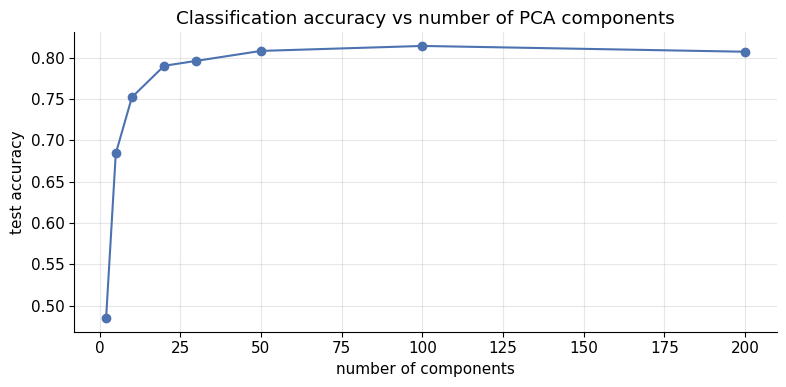

accuracy by #components: {2: 0.485, 5: 0.684, 10: 0.752, 20: 0.79, 30: 0.796, 50: 0.808, 100: 0.814, 200: 0.807}


In [8]:
# Accuracy vs number of PCA components: most of the signal lives in a few dozen dimensions.
comps = [2, 5, 10, 20, 30, 50, 100, 200]
accs = []
for k in comps:
    s = Standardizer().fit(pca.transform(X_train, k=k))
    Atr, Ate = s.transform(pca.transform(X_train, k=k)), s.transform(pca.transform(X_test, k=k))
    accs.append(accuracy(y_test, SoftmaxRegression(n_iter=300).fit(Atr, y_train).predict(Ate)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(comps, accs, "o-", color="#4C72B0")
ax.set_title("Classification accuracy vs number of PCA components")
ax.set_xlabel("number of components"); ax.set_ylabel("test accuracy")
plt.tight_layout(); plt.show()
print("accuracy by #components:", {k: round(a, 3) for k, a in zip(comps, accs)})

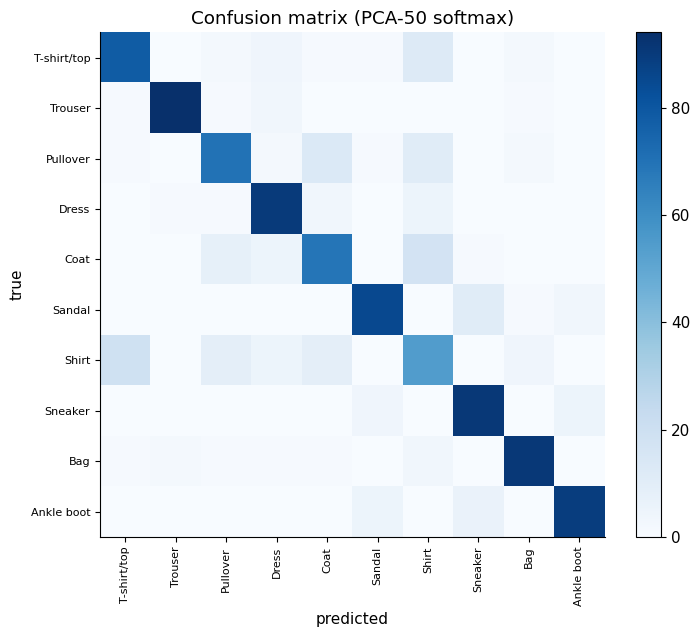

In [9]:
# Per-class confusion for the 50-component softmax model.
def confusion_matrix(y_true, y_pred, k):
    cm = np.zeros((k, k), int)
    for t, p in zip(np.asarray(y_true, int), np.asarray(y_pred, int)):
        cm[t, p] += 1
    return cm

cm = confusion_matrix(y_test, soft.predict(Zte), 10)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues"); fig.colorbar(im, fraction=0.046)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=90, fontsize=8); ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix (PCA-50 softmax)")
ax.grid(False)
plt.tight_layout(); plt.show()

## 3. PCA as compression: reconstructing from $k$ components

Reconstructing an image from its first $k$ components, $\hat X = Z_k V_k^\top + \bar X$, is a form of lossy compression: 784 pixels become $k$ numbers. The reconstructions show how quickly the garment becomes recognisable as $k$ grows.

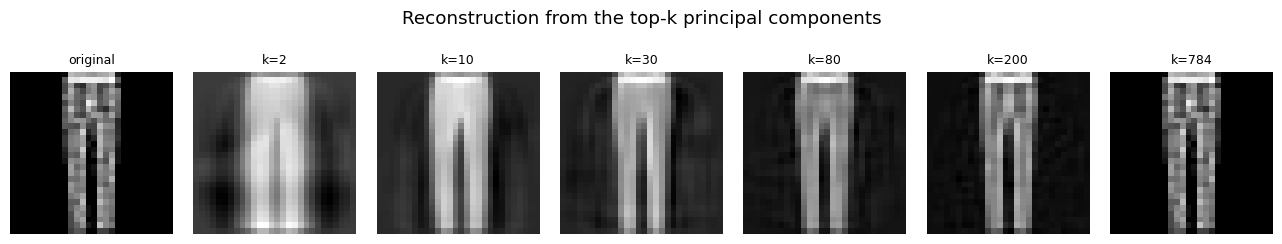

In [10]:
sample = X_test[7]
ks = [2, 10, 30, 80, 200, 784]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(13, 2.3))
axes[0].imshow(sample.reshape(28, 28), cmap="gray"); axes[0].set_title("original", fontsize=9)
for ax, k in zip(axes[1:], ks):
    z = pca.transform(sample[None, :], k=k)
    rec = pca.inverse_transform(z).reshape(28, 28)
    ax.imshow(rec, cmap="gray"); ax.set_title(f"k={k}", fontsize=9)
for ax in axes: ax.axis("off")
fig.suptitle("Reconstruction from the top-k principal components", y=1.05)
plt.tight_layout(); plt.show()

## 4. Reconstruction error vs $k$: compression, quantified

Section 3 showed the reconstructions "look" right by a few dozen components; here I put a number on it. Reconstructing from the top $k$ components and measuring the mean squared pixel error,

$$
\mathrm{MSE}(k) = \frac{1}{n\,d}\,\lVert X - \hat X_k \rVert_F^2,
$$

should fall as $k$ grows. PCA theory makes a sharp prediction - the leftover error equals the variance held by the discarded components, $\mathrm{MSE}(k) \approx \tfrac{1}{d}\sum_{i>k}\lambda_i$ - so I overlay the empirical curve on that eigenvalue tail.

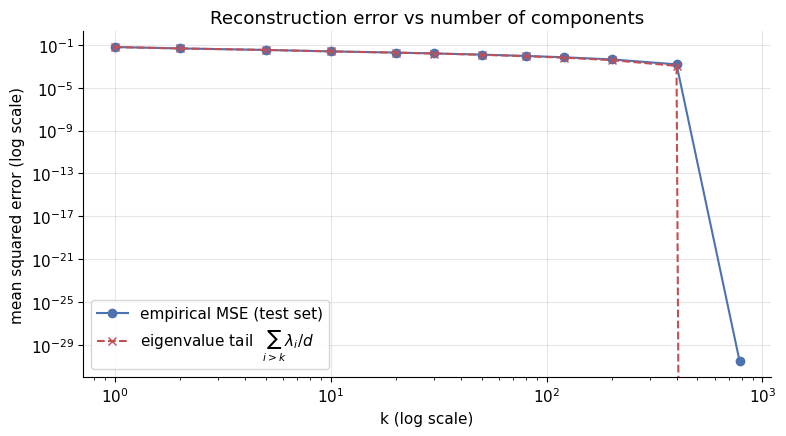

k =  10: test MSE = 0.02455
k =  50: test MSE = 0.01225
k = 200: test MSE = 0.00437


In [11]:
# mean squared reconstruction error on the test set vs k, compared to the eigenvalue-tail prediction.
ks = [1, 2, 5, 10, 20, 30, 50, 80, 120, 200, 400, 784]
mse_emp = []
for k in ks:
    rec = pca.inverse_transform(pca.transform(X_test, k=k))
    mse_emp.append(float(np.mean((X_test - rec) ** 2)))

# PCA theory: leftover error per pixel = variance held by the discarded components.
tail = np.array([pca.eigenvalues_[k:].sum() for k in ks]) / X_test.shape[1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ks, mse_emp, "o-", color="#4C72B0", label="empirical MSE (test set)")
ax.plot(ks, tail, "x--", color="#C44E52", label=r"eigenvalue tail  $\sum_{i>k}\lambda_i / d$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Reconstruction error vs number of components")
ax.set_xlabel("k (log scale)"); ax.set_ylabel("mean squared error (log scale)"); ax.legend()
plt.tight_layout(); plt.show()

for k in [10, 50, 200]:
    print(f"k = {k:>3}: test MSE = {mse_emp[ks.index(k)]:.5f}")

The two curves track each other closely - PCA's promise made concrete: the error you pay for dropping components is precisely the variance those components held. The error falls steeply and then flattens, the same diminishing returns the scree plot hinted at, so a few dozen components really are a cheap, near-lossless summary of each garment.